## CESM3 hist2ts

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['PATH'] = '/glade/u/apps/derecho/24.12/spack/opt/spack/nco/5.3.1/gcc/12.4.0/vih5/bin' + ':' + os.environ['PATH']
os.chdir('/glade/u/home/fengzhu/Github/x4c/docsrc/notebooks')
import numpy as np
import x4c
print(x4c.__version__)

2024.8.13


In [2]:
dirpath = os.path.join('/glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e30_beta02.BLT1850.ne30_t232.104')
case = x4c.History(
    dirpath,
    casename='b.e30_beta02.BLT1850.ne30_t232.104',
    path_pattern='comp/hist/casename.mdl.h_str.date.nc',
    mdl_hstr_dict={
        'ocn': ('mom6', 'h.native'),
        'atm': ('cam', 'h0a'),
        'rof': ('mosart', 'h0'),
    }
)

>>> case.root_dir: /glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e30_beta02.BLT1850.ne30_t232.104
>>> case.casename: b.e30_beta02.BLT1850.ne30_t232.104
>>> case.comps_info: {'atm': ('cam', 'h0a'), 'ocn': ('mom6', 'h.native'), 'lnd': ('clm2', 'h0'), 'ice': ('cice', 'h'), 'rof': ('mosart', 'h0')}
>>> case.paths["atm"] created
>>> case.paths["ocn"] created
>>> case.paths["lnd"] created
>>> case.paths["ice"] created
>>> case.paths["rof"] created
>>> case.vns["atm"] created
>>> case.vns["ocn"] created
>>> case.vns["lnd"] created
>>> case.vns["ice"] created
>>> case.vns["rof"] created


In [3]:
case = x4c.History(
    dirpath,
    casename='b.e30_beta02.BLT1850.ne30_t232.104',
    cesm_ver=3,
)

>>> case.root_dir: /glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e30_beta02.BLT1850.ne30_t232.104
>>> case.casename: b.e30_beta02.BLT1850.ne30_t232.104
>>> case.comps_info: {'atm': ('cam', 'h0a'), 'ocn': ('mom6', 'h.native'), 'lnd': ('clm2', 'h0'), 'ice': ('cice', 'h'), 'rof': ('mosart', 'h0')}
>>> case.paths["atm"] created
>>> case.paths["ocn"] created
>>> case.paths["lnd"] created
>>> case.paths["ice"] created
>>> case.paths["rof"] created
>>> case.vns["atm"] created
>>> case.vns["ocn"] created
>>> case.vns["lnd"] created
>>> case.vns["ice"] created
>>> case.vns["rof"] created


## atm

In [4]:
ds = x4c.open_dataset(case.paths['atm'][0])
ds

<xarray.Dataset> Size: 941MB
Dimensions:         (lat: 192, lon: 288, lev: 58, ilev: 59, trop_pref: 58,
                     trop_prefi: 59, trop_cld_lev: 58, time: 1, nbnd: 2)
Coordinates:
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.3 357.5 358.8
  * lev             (lev) float64 464B 3.018 5.445 9.087 ... 983.2 991.2 997.5
  * ilev            (ilev) float64 472B 2.055 3.98 6.909 ... 987.4 995.1 1e+03
  * trop_pref       (trop_pref) float64 464B 3.018 5.445 9.087 ... 991.2 997.5
  * trop_prefi      (trop_prefi) float64 472B 2.055 3.98 6.909 ... 995.1 1e+03
  * trop_cld_lev    (trop_cld_lev) float64 464B 3.018 5.445 ... 991.2 997.5
  * time            (time) object 8B 0001-01-16 12:00:00
Dimensions without coordinates: nbnd
Data variables: (12/218)
    w               (lat) float64 2kB ...
    hyam            (lev) float64 464B ...
    hybm            (lev) float64 464B ...
    hyai            (ilev) float64 472B ...
    hybi            (ilev) float64 472B ...
    date            (time) int32 4B ...
    ...              ...
    ZMDQ            (time, lev, lat, lon) float32 13MB ...
    ZMDT            (time, lev, lat, lon) float32 13MB ...
    CMFMC_DP        (time, ilev, lat, lon) float32 13MB ...
    PINT            (time, ilev, lat, lon) float32 13MB ...
    WPTHLP_CLUBB    (time, ilev, lat, lon) float32 13MB ...
    WPRTP_CLUBB     (time, ilev, lat, lon) float32 13MB ...
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e30_beta02.BLT1850.ne30_t232.104
    logname:           hannay
    host:              dec0099
    initial_file:      b.e23_alpha17f.BLT1850.ne30_t232.098.cam.i.0201-01-01-...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     not_set
    time_period_freq:  month_1
    path:              /glade/campaign/cesm/development/cross-wg/diagnostic_f...

In [5]:
%%time

case.gen_ts(
    # comps=['atm'],
    comps={'atm': ['TS']},
    output_dirpath=os.path.join('/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries', case.casename),
    scratch_dirpath=os.path.join('/glade/derecho/scratch/fengzhu/x4c/gen_ts/test', case.casename),
    timespan=(1, 20),
    timestep=20,
    nproc=1,
    overwrite=True,
)

>>> Processing component: atm
>>> Processing timespan: (1, 20)


Merging variables: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]

>>> Postprocessing component: atm
>>> Postprocessing timespan: (1, 20)



Moving generated files
from: /glade/derecho/scratch/fengzhu/x4c/gen_ts/test/b.e30_beta02.BLT1850.ne30_t232.104
to: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e30_beta02.BLT1850.ne30_t232.104
Moving generated files [00:00<?, ?it/s]
from: /glade/derecho/scratch/fengzhu/x4c/gen_ts/test/b.e30_beta02.BLT1850.ne30_t232.104
to: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e30_beta02.BLT1850.ne30_t232.104
: 100%|██████████| 1/1 [00:00<00:00, 633.10it/s]


CPU times: user 304 ms, sys: 143 ms, total: 448 ms
Wall time: 1min 1s


In [6]:
ds = x4c.open_dataset(
    '/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e30_beta02.BLT1850.ne30_t232.104/atm/proc/tseries/month_1/b.e30_beta02.BLT1850.ne30_t232.104.cam.h0a.TS.000101-002012.nc',
)
ds

<xarray.Dataset> Size: 53MB
Dimensions:       (time: 240, lat: 192, lon: 288, ilev: 59, lev: 58, nbnd: 2,
                   trop_cld_lev: 58, trop_pref: 58, trop_prefi: 59)
Coordinates:
  * ilev          (ilev) float64 472B 2.055 3.98 6.909 ... 987.4 995.1 1e+03
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lev           (lev) float64 464B 3.018 5.445 9.087 ... 983.2 991.2 997.5
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.3 357.5 358.8
  * time          (time) object 2kB 0001-01-16 12:00:00 ... 0020-12-16 12:00:00
  * trop_cld_lev  (trop_cld_lev) float64 464B 3.018 5.445 9.087 ... 991.2 997.5
  * trop_pref     (trop_pref) float64 464B 3.018 5.445 9.087 ... 991.2 997.5
  * trop_prefi    (trop_prefi) float64 472B 2.055 3.98 6.909 ... 995.1 1e+03
Dimensions without coordinates: nbnd
Data variables: (12/16)
    TS            (time, lat, lon) float32 53MB ...
    date          (time) int32 960B ...
    date_written  (time) |S8 2kB ...
    datesec       (time) int32 960B ...
    hyai          (ilev) float64 472B ...
    hyam          (lev) float64 464B ...
    ...            ...
    nbsec         int32 4B ...
    ndbase        int32 4B ...
    nsbase        int32 4B ...
    time_bounds   (time, nbnd) object 4kB ...
    time_written  (time) |S8 2kB ...
    w             (lat) float64 2kB ...
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e30_beta02.BLT1850.ne30_t232.104
    logname:           hannay
    host:              dec0099
    initial_file:      b.e23_alpha17f.BLT1850.ne30_t232.098.cam.i.0201-01-01-...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     not_set
    time_period_freq:  month_1
    path:              /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries...

In [10]:
ds['TS']

<xarray.DataArray 'TS' (time: 240, lat: 192, lon: 288)> Size: 53MB
[13271040 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
  * time     (time) object 2kB 0001-01-16 12:00:00 ... 0020-12-16 12:00:00
Attributes:
    units:         K
    long_name:     Surface temperature (radiative)
    cell_methods:  time: mean

In [12]:
da = ds['TS'].x.annualize() - 273.15
da.attrs['units'] = '°C'
da.attrs['comp'] = 'atm'
da

<xarray.DataArray 'TS' (time: 20, lat: 192, lon: 288)> Size: 4MB
array([[[-53.957047, -53.957047, -53.957047, ..., -53.957047,
         -53.957047, -53.957047],
        [-52.540314, -52.576035, -52.61241 , ..., -52.437027,
         -52.470795, -52.505234],
        [-51.30887 , -51.367477, -51.42697 , ..., -51.139145,
         -51.194656, -51.25125 ],
        ...,
        [-17.12146 , -17.090637, -17.060303, ..., -17.216537,
         -17.184464, -17.152802],
        [-17.511337, -17.49913 , -17.487106, ..., -17.548859,
         -17.536224, -17.523712],
        [-17.783783, -17.783783, -17.783783, ..., -17.783783,
         -17.783783, -17.783783]],

       [[-53.15358 , -53.15358 , -53.15358 , ..., -53.15358 ,
         -53.15358 , -53.15358 ],
        [-51.731705, -51.769943, -51.808823, ..., -51.620987,
         -51.65721 , -51.694138],
        [-50.48178 , -50.548798, -50.616745, ..., -50.28694 ,
         -50.350784, -50.415787],
...
        [-19.329086, -19.323105, -19.317184, ..., -19.34726 ,
         -19.341156, -19.335098],
        [-19.364792, -19.362991, -19.361176, ..., -19.37027 ,
         -19.368423, -19.366623],
        [-19.389542, -19.389542, -19.389542, ..., -19.389542,
         -19.389542, -19.389542]],

       [[-55.421906, -55.421906, -55.421906, ..., -55.421906,
         -55.421906, -55.421906],
        [-54.133347, -54.167953, -54.2032  , ..., -54.03325 ,
         -54.066025, -54.09938 ],
        [-52.941193, -53.0007  , -53.061127, ..., -52.76889 ,
         -52.82524 , -52.88266 ],
        ...,
        [-19.35051 , -19.33461 , -19.318954, ..., -19.399399,
         -19.38295 , -19.366623],
        [-19.5103  , -19.50386 , -19.497513, ..., -19.529922,
         -19.523346, -19.5168  ],
        [-19.586517, -19.586517, -19.586517, ..., -19.586517,
         -19.586517, -19.586517]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
  * time     (time) object 160B 0001-12-31 00:00:00 ... 0020-12-31 00:00:00
Attributes:
    units:         °C
    long_name:     Surface temperature (radiative)
    cell_methods:  time: mean
    comp:          atm

CPU times: user 1.35 s, sys: 3.48 ms, total: 1.35 s
Wall time: 1.38 s


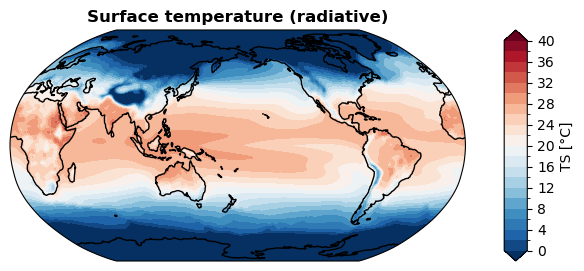

In [14]:
%%time
fig, ax = da.mean('time').x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
    cyclic=True,
)

CPU times: user 1.34 s, sys: 9.12 ms, total: 1.35 s
Wall time: 1.35 s


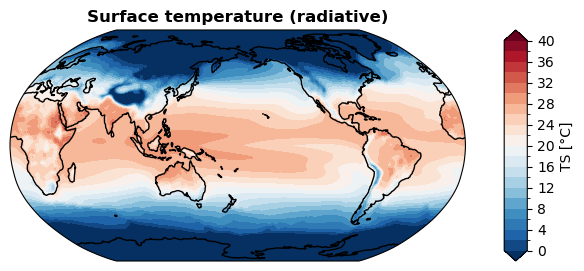

In [15]:
%%time
fig, ax = da.mean('time').x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
    cyclic=True,
    ux=True,
)

## ocn

In [16]:
ds = x4c.open_dataset(case.paths['ocn'][0])
ds

<xarray.Dataset> Size: 2GB
Dimensions:               (scalar_axis: 1, time: 1, nbnd: 2, xq: 540, yh: 480,
                           zl: 75, xh: 540, yq: 480, zi: 76)
Coordinates:
  * scalar_axis           (scalar_axis) float64 8B 0.0
  * time                  (time) object 8B 0001-01-16 12:00:00
  * nbnd                  (nbnd) float64 16B 1.0 2.0
  * xq                    (xq) float64 4kB -286.3 -285.7 -285.0 ... 72.33 73.0
  * yh                    (yh) float64 4kB -81.56 -81.46 -81.36 ... 87.71 87.74
  * zl                    (zl) float64 600B 1.25 3.75 ... 4.58e+03 5.506e+03
  * xh                    (xh) float64 4kB -286.7 -286.0 -285.3 ... 72.0 72.67
  * yq                    (yq) float64 4kB -81.51 -81.41 -81.31 ... 87.73 87.74
  * zi                    (zi) float64 608B 0.0 2.5 5.0 ... 5.012e+03 6e+03
Data variables: (12/82)
    soga                  (time, scalar_axis) float32 4B ...
    thetaoga              (time, scalar_axis) float32 4B ...
    uh                    (time, zl, yh, xq) float32 78MB ...
    vh                    (time, zl, yq, xh) float32 78MB ...
    vhbt                  (time, yq, xh) float32 1MB ...
    uhbt                  (time, yh, xq) float32 1MB ...
    ...                    ...
    ice_fraction          (time, yh, xh) float32 1MB ...
    u10_sqr               (time, yh, xh) float32 1MB ...
    average_T1            (time) object 8B ...
    average_T2            (time) object 8B ...
    average_DT            (time) timedelta64[ns] 8B ...
    time_bounds           (time, nbnd) object 16B ...
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: b.e30_beta...
    associated_files:  areacello: b.e30_beta02.BLT1850.ne30_t232.104.mom6.h.s...
    grid_type:         regular
    grid_tile:         N/A
    path:              /glade/campaign/cesm/development/cross-wg/diagnostic_f...

In [17]:
case.gen_ts(
    # comps=['ocn'],
    comps={'ocn': ['tos']},
    output_dirpath=os.path.join('/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries', case.casename),
    scratch_dirpath=os.path.join('/glade/derecho/scratch/fengzhu/x4c/gen_ts/test', case.casename),
    timespan=(1, 20),
    timestep=20,
    nproc=1,
    overwrite=True,
)

>>> Processing component: ocn
>>> Processing timespan: (1, 20)


Merging variables: 100%|██████████| 1/1 [00:02<00:00,  2.85s/it]


>>> Postprocessing component: ocn
>>> Postprocessing timespan: (1, 20)


Moving generated files
from: /glade/derecho/scratch/fengzhu/x4c/gen_ts/test/b.e30_beta02.BLT1850.ne30_t232.104
to: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e30_beta02.BLT1850.ne30_t232.104
Moving generated files [00:00<?, ?it/s]
from: /glade/derecho/scratch/fengzhu/x4c/gen_ts/test/b.e30_beta02.BLT1850.ne30_t232.104
to: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e30_beta02.BLT1850.ne30_t232.104
: 100%|██████████| 1/1 [00:00<00:00, 554.14it/s]


In [19]:
ds = x4c.open_dataset(
    '/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e30_beta02.BLT1850.ne30_t232.104/ocn/proc/tseries/month_1/b.e30_beta02.BLT1850.ne30_t232.104.h.native.tos.000101-002012.nc',
)
ds

<xarray.Dataset> Size: 249MB
Dimensions:      (time: 240, nbnd: 2, scalar_axis: 1, yh: 480, xh: 540,
                  xq: 540, yq: 480, zi: 76, zl: 75)
Coordinates:
  * nbnd         (nbnd) float64 16B 1.0 2.0
  * scalar_axis  (scalar_axis) float64 8B 0.0
  * time         (time) object 2kB 0001-01-16 12:00:00 ... 0020-12-16 12:00:00
  * xh           (xh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * xq           (xq) float64 4kB -286.3 -285.7 -285.0 ... 71.67 72.33 73.0
  * yh           (yh) float64 4kB -81.56 -81.46 -81.36 ... 87.65 87.71 87.74
  * yq           (yq) float64 4kB -81.51 -81.41 -81.31 ... 87.68 87.73 87.74
  * zi           (zi) float64 608B 0.0 2.5 5.0 7.5 ... 4.149e+03 5.012e+03 6e+03
  * zl           (zl) float64 600B 1.25 3.75 6.25 ... 4.58e+03 5.506e+03
Data variables:
    average_DT   (time) timedelta64[ns] 2kB ...
    average_T1   (time) object 2kB ...
    average_T2   (time) object 2kB ...
    time_bounds  (time, nbnd) object 4kB ...
    tos          (time, yh, xh) float32 249MB ...
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: b.e30_beta...
    associated_files:  areacello: b.e30_beta02.BLT1850.ne30_t232.104.mom6.h.s...
    grid_type:         regular
    grid_tile:         N/A
    path:              /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries...

In [20]:
da = ds['tos'].x.annualize()
da.attrs['units'] = '°C'
da.attrs['comp'] = 'ocn'
da.attrs['grid'] = 't232'
da

<xarray.DataArray 'tos' (time: 20, yh: 480, xh: 540)> Size: 21MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * xh       (xh) float64 4kB -286.7 -286.0 -285.3 -284.7 ... 71.33 72.0 72.67
  * yh       (yh) float64 4kB -81.56 -81.46 -81.36 -81.26 ... 87.65 87.71 87.74
  * time     (time) object 160B 0001-12-31 00:00:00 ... 0020-12-31 00:00:00
Attributes:
    units:          °C
    long_name:      Sea Surface Temperature
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature
    comp:           ocn
    grid:           t232

In [58]:
%%time
fig, ax = da.mean('time').x.regrid().x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
)

AttributeError: 'Dataset' object has no attribute 'TLAT'